# Human Evaluation of CFE: Comparison (Filtered vs Non-Filtered) with Statistical Significance

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import squarify
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, mannwhitneyu

from survey_parser import load_config, parse_results

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

survey_config = load_config('config.json')
df_unfiltered = pd.read_csv('results.csv')
df_filtered = pd.read_csv('results_filtered.csv')

# Define df_excluded
topsis_col = 'q15_topsis_pos'
ip_col = 'q15_IP_pos'
if topsis_col in df_unfiltered.columns and ip_col in df_unfiltered.columns:
    df_unfiltered['q15_dupe_dist'] = (df_unfiltered[topsis_col] - df_unfiltered[ip_col]).abs()
    df_excluded = df_unfiltered[df_unfiltered['q15_dupe_dist'] > 1].copy()
else:
    df_excluded = pd.DataFrame(columns=df_unfiltered.columns)

parsed_results_unfiltered = parse_results(survey_config, 'results.csv')
parsed_results_filtered = parse_results(survey_config, 'results_filtered.csv')
# Excluded parsed results would require a temp csv, but we can compute counts manually where needed.

ranking_qs = [q.id for q in survey_config.ranking_questions if q.images]
selectors = ['IP', 'BP', 'RP', 'topsis']

def run_chi2(obs, name):
    # obs is a 2D array: [filtered_counts, excluded_counts]
    if np.sum(obs[0]) == 0 or np.sum(obs[1]) == 0:
        print(f"{name}: Not enough data for Chi-Square.")
        return
    try:
        chi2, p, dof, expected = chi2_contingency(obs)
        sig = "*** SIGNIFICANT ***" if p < 0.05 else "Not significant"
        print(f"{name}: p-value = {p:.4f} ({sig})")
    except Exception as e:
        print(f"{name}: Chi-Square failed ({e})")


## 1. Distribution of Human Rankings across all 5 CelebA Instances

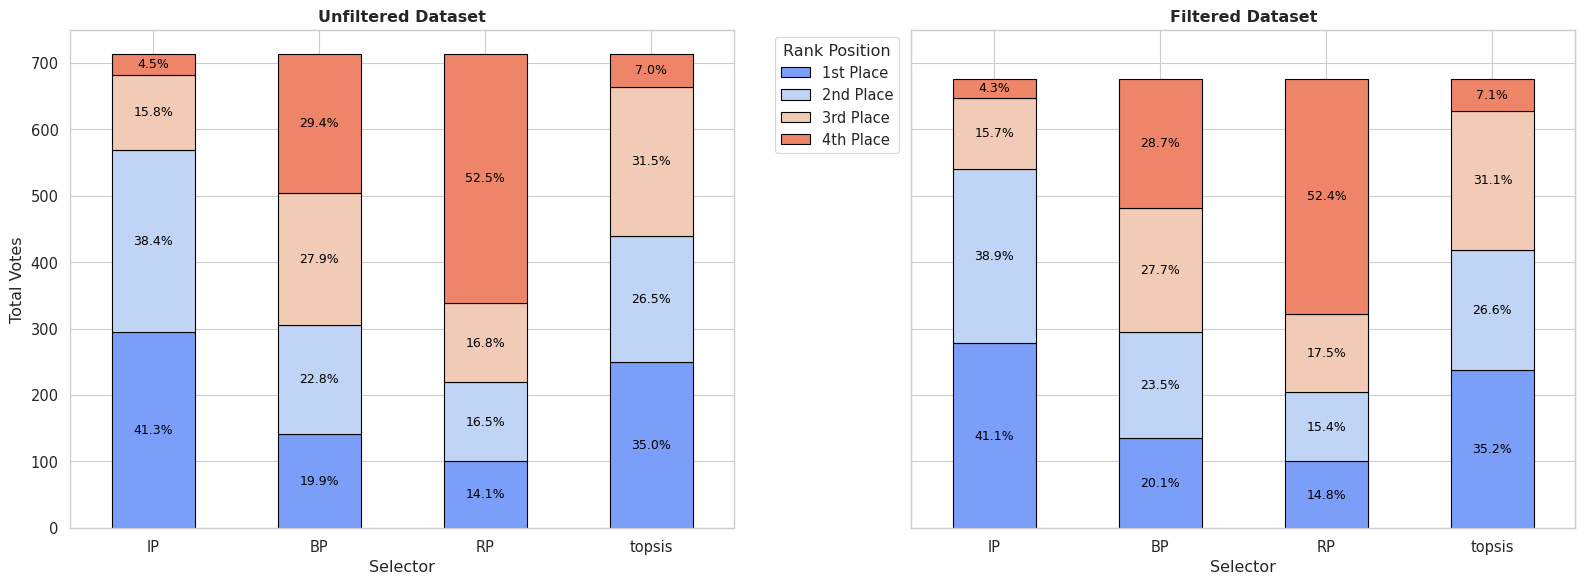

--- Statistical Significance (Filtered vs Excluded) ---
Selector 'IP' Rank Distribution: p-value = 0.5208 (Not significant)
Selector 'BP' Rank Distribution: p-value = 0.1449 (Not significant)
Selector 'RP' Rank Distribution: p-value = 0.0007 (*** SIGNIFICANT ***)
Selector 'topsis' Rank Distribution: p-value = 0.7449 (Not significant)


In [16]:
def get_agg_counts(parsed_results):
    agg_counts = {s: {1: 0, 2: 0, 3: 0, 4: 0} for s in selectors}
    for q_id in ranking_qs:
        for s in selectors:
            for rank, count in parsed_results[q_id].ranking_counts.get(s, {}).items():
                agg_counts[s][rank] += count
    return agg_counts

agg_unfiltered = get_agg_counts(parsed_results_unfiltered)
agg_filtered = get_agg_counts(parsed_results_filtered)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
def plot_rank_dist(agg_counts, ax, title):
    total_ranks = next(map(lambda ds: sum(ds.values()), agg_counts.values()))
    agg_df = pd.DataFrame(agg_counts).T
    agg_df.columns = ['1st Place', '2nd Place', '3rd Place', '4th Place']
    colors = sns.color_palette("coolwarm", 4)
    agg_df.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')
    
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5:
            x, y = p.get_xy() 
            ax.text(x + width/2, y + height/2, f'{height / total_ranks * 100:.1f}%', 
                    ha='center', va='center', fontsize=9, color='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Selector')
    ax.set_ylabel('Total Votes')
    ax.tick_params(axis='x', rotation=0)
    
plot_rank_dist(agg_unfiltered, axes[0], 'Unfiltered Dataset')
plot_rank_dist(agg_filtered, axes[1], 'Filtered Dataset')
axes[0].legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
for s in selectors:
    excluded_counts = [agg_unfiltered[s][r] - agg_filtered[s][r] for r in [1,2,3,4]]
    filtered_counts = list(agg_filtered[s].values())
    run_chi2([filtered_counts, excluded_counts], f"Selector '{s}' Rank Distribution")


## 2. Distribution of Human Rankings by Explainer

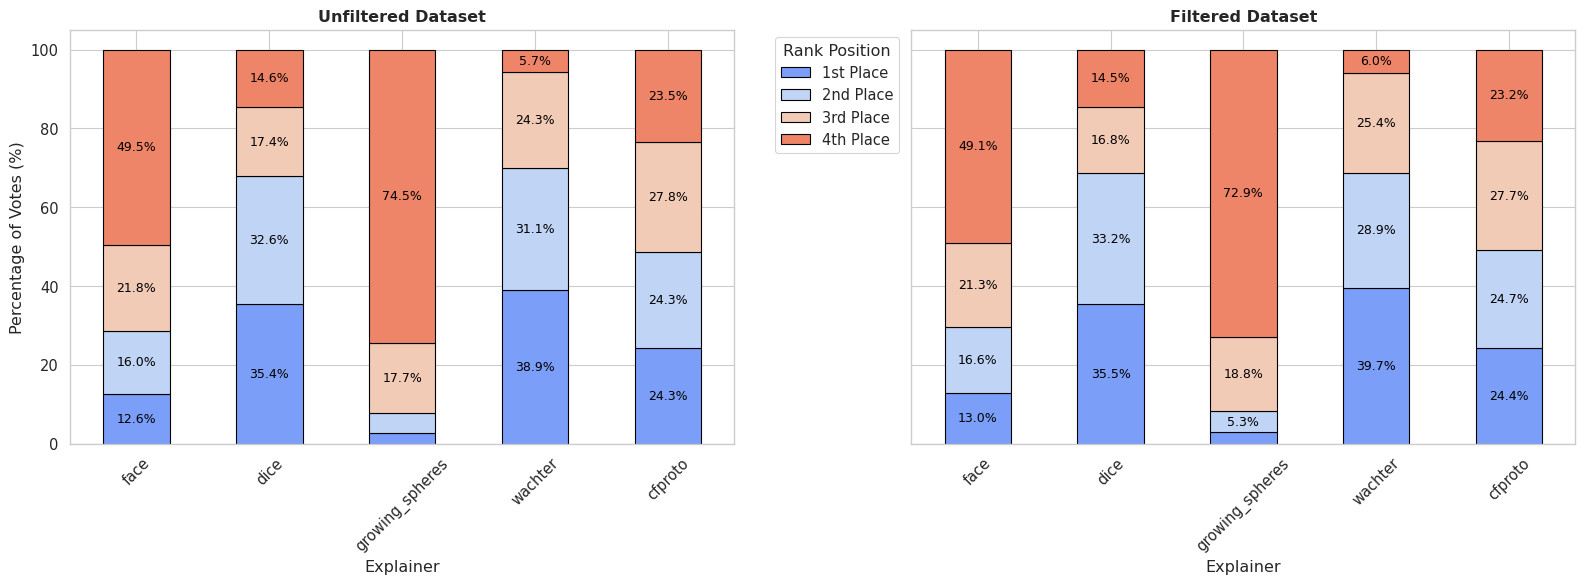

--- Statistical Significance (Filtered vs Excluded) ---
Explainer 'face' Rank Distribution: p-value = 0.4939 (Not significant)
Explainer 'dice' Rank Distribution: p-value = 0.2208 (Not significant)
Explainer 'growing_spheres' Rank Distribution: p-value = 0.4061 (Not significant)
Explainer 'wachter' Rank Distribution: p-value = 0.0005 (*** SIGNIFICANT ***)
Explainer 'cfproto' Rank Distribution: p-value = 0.5139 (Not significant)


In [17]:
import pickle
import sys
import os
sys.path.append(os.path.abspath('../../src'))
from explainers_lib.ensemble import cfs_group_by_original_data

PICKLE_FILE_PATH = "../results/evaluate_selectors_celeba_20260313_071238.pkl"
EXTRA_CFS = "../results/evaluate_selectors_celeba_20260421_123022_dice_face_after_fix.pkl"

with open(PICKLE_FILE_PATH, "rb") as f:
    all_generated_cfes = pickle.load(f)
with open(EXTRA_CFS, "rb") as f:
    extra_cfs = pickle.load(f)
extra_cfs = filter(lambda cfe: cfe.original_class == 1, extra_cfs)
all_generated_cfes.extend(extra_cfs)

grouped_cfs = cfs_group_by_original_data(all_generated_cfes)
import re
regex = re.compile(r"(_explainer)?\(.*\)")
qid_to_cfe_id = { q: int(q[1:]) for q in ranking_qs }
cfs = list(grouped_cfs.values())
cfs = [cfs[idx] for idx in qid_to_cfe_id.values()]
cfs_methods = list(map(lambda cfe_i: list(map(lambda cf: regex.sub("", cf.explainer), cfe_i)), cfs))
all_methods = list({item for sublist in cfs_methods for item in sublist})

with open("../results/evaluate_selectors_celeba_20260423_172842_scores.pkl", "rb") as f:
    scores = pickle.load(f)
    results_by_selector = scores["results_by_selector"]

sel_to_s = { sel: s for sel, s in zip(sorted(results_by_selector.keys() - ["ParetoMeanPoint"], key = lambda k: k[0]), sorted(selectors, key = lambda k: k[0]))}

def get_explainer_agg(parsed_results):
    agg_counts = {s: {1: 0, 2: 0, 3: 0, 4: 0} for s in all_methods}
    for i, q_id in enumerate(ranking_qs):
        seen_sel = {"ParetoMeanPoint"}
        for cf in cfs[i]:
            for sel in results_by_selector:
                if sel in seen_sel: continue
                if cf.data.tobytes() in results_by_selector[sel]:
                    seen_sel.add(sel)
                    for rank, count in parsed_results[q_id].ranking_counts.get(sel_to_s[sel], {}).items():
                        agg_counts[regex.sub("", cf.explainer)][rank] += count
    return agg_counts

exp_agg_unf = get_explainer_agg(parsed_results_unfiltered)
exp_agg_fil = get_explainer_agg(parsed_results_filtered)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
def plot_explainer_dist(agg_counts, ax, title):
    agg_df = pd.DataFrame(agg_counts).T
    agg_df.columns = ['1st Place', '2nd Place', '3rd Place', '4th Place']
    agg_pct = agg_df.div(agg_df.sum(axis=1), axis=0) * 100
    colors = sns.color_palette("coolwarm", 4)
    agg_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Explainer')
    ax.set_ylabel('Percentage of Votes (%)')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5:
            x, y = p.get_xy() 
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='black')

plot_explainer_dist(exp_agg_unf, axes[0], 'Unfiltered Dataset')
plot_explainer_dist(exp_agg_fil, axes[1], 'Filtered Dataset')
axes[0].legend(title='Rank Position', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
for exp in all_methods:
    excluded_counts = [exp_agg_unf[exp][r] - exp_agg_fil[exp][r] for r in [1,2,3,4]]
    filtered_counts = list(exp_agg_fil[exp].values())
    run_chi2([filtered_counts, excluded_counts], f"Explainer '{exp}' Rank Distribution")


## 3. What had the greatest impact on evaluation?

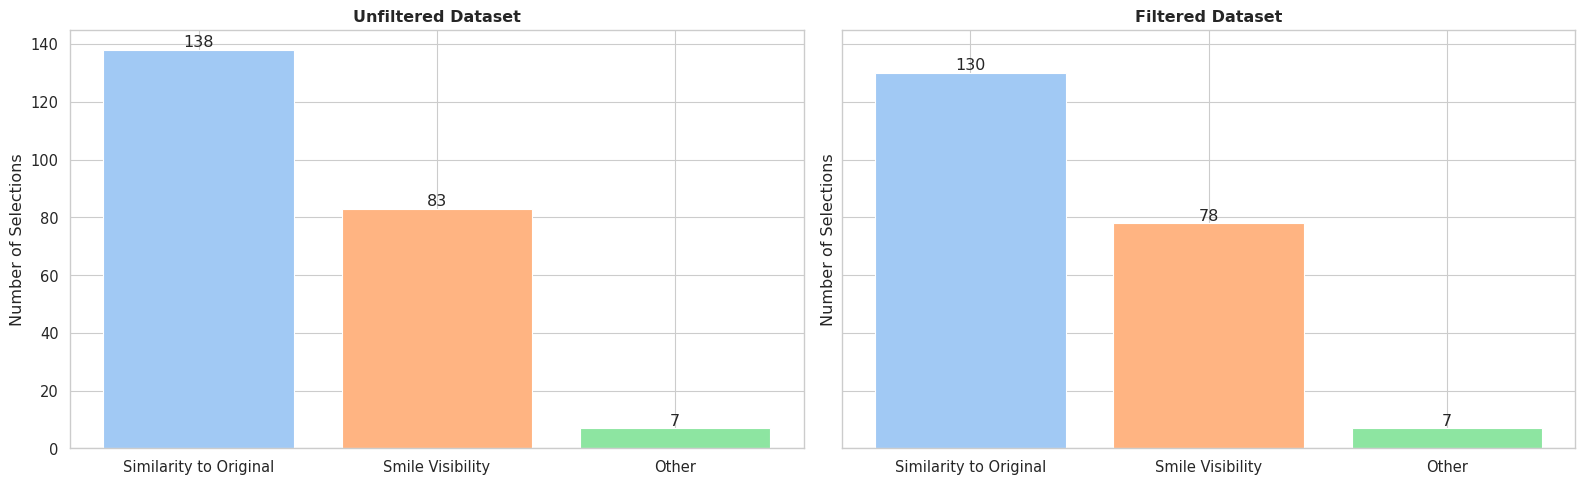

--- Statistical Significance (Filtered vs Excluded) ---
Primary Criterion Choice: p-value = 0.8019 (Not significant)


In [18]:
labels = {'similarity': 'Similarity to Original', 'smile': 'Smile Visibility', 'other': 'Other'}

def get_primary_crit_counts(parsed_results):
    criteria_counts = parsed_results['q_most_important_criterion'].counts
    return {labels.get(k, k): v for k, v in criteria_counts.items() if v > 0}

crit_unf = get_primary_crit_counts(parsed_results_unfiltered)
crit_fil = get_primary_crit_counts(parsed_results_filtered)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
def plot_primary_criterion(mapped_counts, ax, title):
    ax.bar(mapped_counts.keys(), mapped_counts.values(), color=sns.color_palette("pastel"))
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Number of Selections')
    for i, v in enumerate(mapped_counts.values()):
        ax.text(i, v + 1, str(v), ha='center')

plot_primary_criterion(crit_unf, axes[0], 'Unfiltered Dataset')
plot_primary_criterion(crit_fil, axes[1], 'Filtered Dataset')
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
keys = list(crit_fil.keys())
filtered_counts = [crit_fil.get(k, 0) for k in keys]
excluded_counts = [crit_unf.get(k, 0) - crit_fil.get(k, 0) for k in keys]
run_chi2([filtered_counts, excluded_counts], "Primary Criterion Choice")


## 4. Implicit Explainer Rankings by Primary Evaluation Criterion

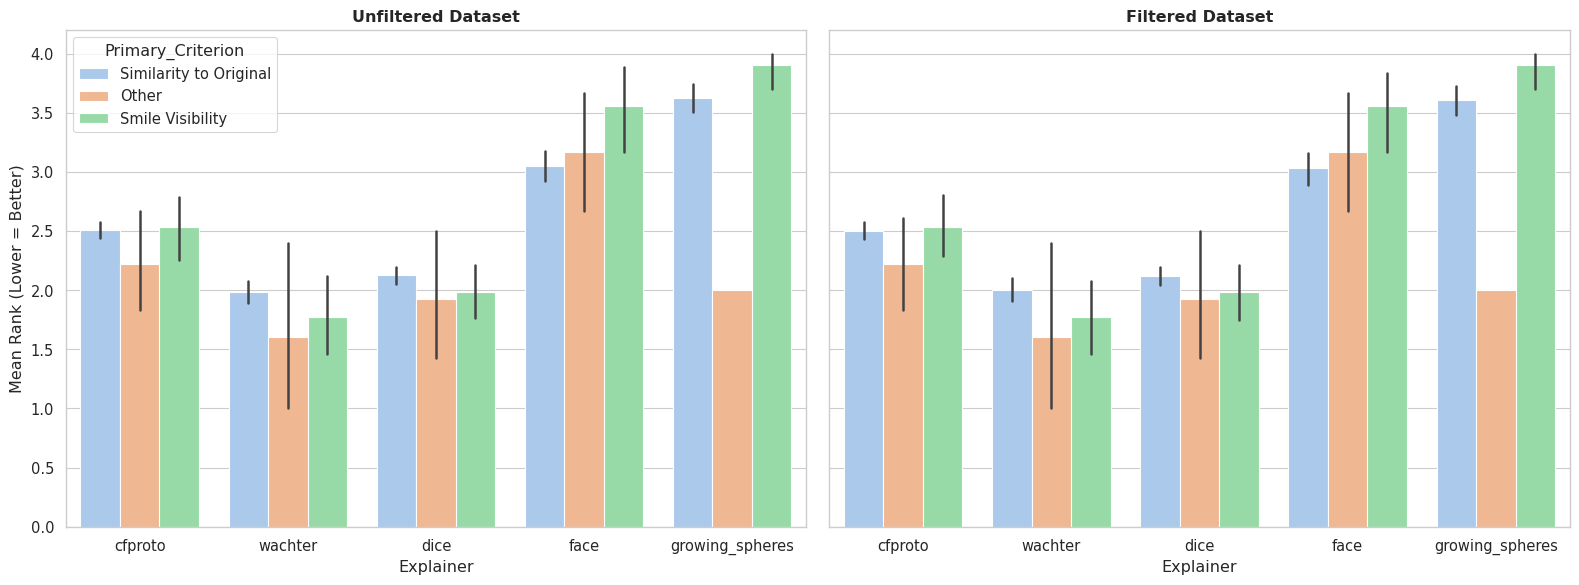

--- Statistical Significance (Filtered vs Excluded - Mann-Whitney U on Ranks) ---
Explainer 'cfproto' | Criterion 'Similarity to Original': p-value = 0.2598 (Not significant)
Explainer 'wachter' | Criterion 'Similarity to Original': p-value = 0.4502 (Not significant)
Explainer 'dice' | Criterion 'Similarity to Original': p-value = 0.3519 (Not significant)
Explainer 'face' | Criterion 'Similarity to Original': p-value = 0.2791 (Not significant)
Explainer 'growing_spheres' | Criterion 'Similarity to Original': p-value = 0.0860 (Not significant)


In [19]:
def get_explainer_ranks(df):
    q_sel_to_explainer = {q: {} for q in ranking_qs}
    for i, q_id in enumerate(ranking_qs):
        seen_sel = {"ParetoMeanPoint"}
        for cf in cfs[i]:
            for sel in results_by_selector:
                if sel in seen_sel: continue
                if cf.data.tobytes() in results_by_selector[sel]:
                    seen_sel.add(sel)
                    q_sel_to_explainer[q_id][sel_to_s[sel]] = regex.sub("", cf.explainer)
                    
    explainer_rows = []
    labels_map = {'similarity': 'Similarity to Original', 'smile': 'Smile Visibility', 'other': 'Other'}
    for idx, row in df.iterrows():
        crit = row.get('q_most_important_criterion')
        if pd.isna(crit) or crit == 'Not Specified': continue
        primary_crit = str(crit).split(';')[0]
        crit_label = labels_map.get(primary_crit, 'Other')
        for q in ranking_qs:
            for s in selectors:
                col = f"{q}_{s}_pos"
                if col in df.columns and pd.notna(row[col]):
                    explainer_name = q_sel_to_explainer[q].get(s, "Unknown")
                    explainer_rows.append({'Subject_ID': idx, 'Explainer': explainer_name, 'Rank': row[col], 'Primary_Criterion': crit_label})
    df_explainer_ranks = pd.DataFrame(explainer_rows)
    return df_explainer_ranks[df_explainer_ranks['Explainer'] != 'Unknown']

df_exp_ranks_unf = get_explainer_ranks(df_unfiltered)
df_exp_ranks_fil = get_explainer_ranks(df_filtered)
df_exp_ranks_exc = get_explainer_ranks(df_excluded)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.barplot(data=df_exp_ranks_unf, x='Explainer', y='Rank', hue='Primary_Criterion', errorbar=('ci', 95), palette='pastel', ax=axes[0])
sns.barplot(data=df_exp_ranks_fil, x='Explainer', y='Rank', hue='Primary_Criterion', errorbar=('ci', 95), palette='pastel', ax=axes[1])
axes[0].set_title('Unfiltered Dataset', fontweight='bold')
axes[1].set_title('Filtered Dataset', fontweight='bold')
axes[0].set_ylabel('Mean Rank (Lower = Better)')
axes[1].set_ylabel('')
axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded - Mann-Whitney U on Ranks) ---")
for exp in df_exp_ranks_fil['Explainer'].unique():
    for crit in df_exp_ranks_fil['Primary_Criterion'].unique():
        f_ranks = df_exp_ranks_fil[(df_exp_ranks_fil['Explainer'] == exp) & (df_exp_ranks_fil['Primary_Criterion'] == crit)]['Rank']
        e_ranks = df_exp_ranks_exc[(df_exp_ranks_exc['Explainer'] == exp) & (df_exp_ranks_exc['Primary_Criterion'] == crit)]['Rank']
        if len(f_ranks) > 0 and len(e_ranks) > 0:
            stat, p = mannwhitneyu(f_ranks, e_ranks, alternative='two-sided')
            sig = "*** SIGNIFICANT ***" if p < 0.05 else "Not significant"
            print(f"Explainer '{exp}' | Criterion '{crit}': p-value = {p:.4f} ({sig})")


## 5. Treemap: Education Level & ML Familiarity

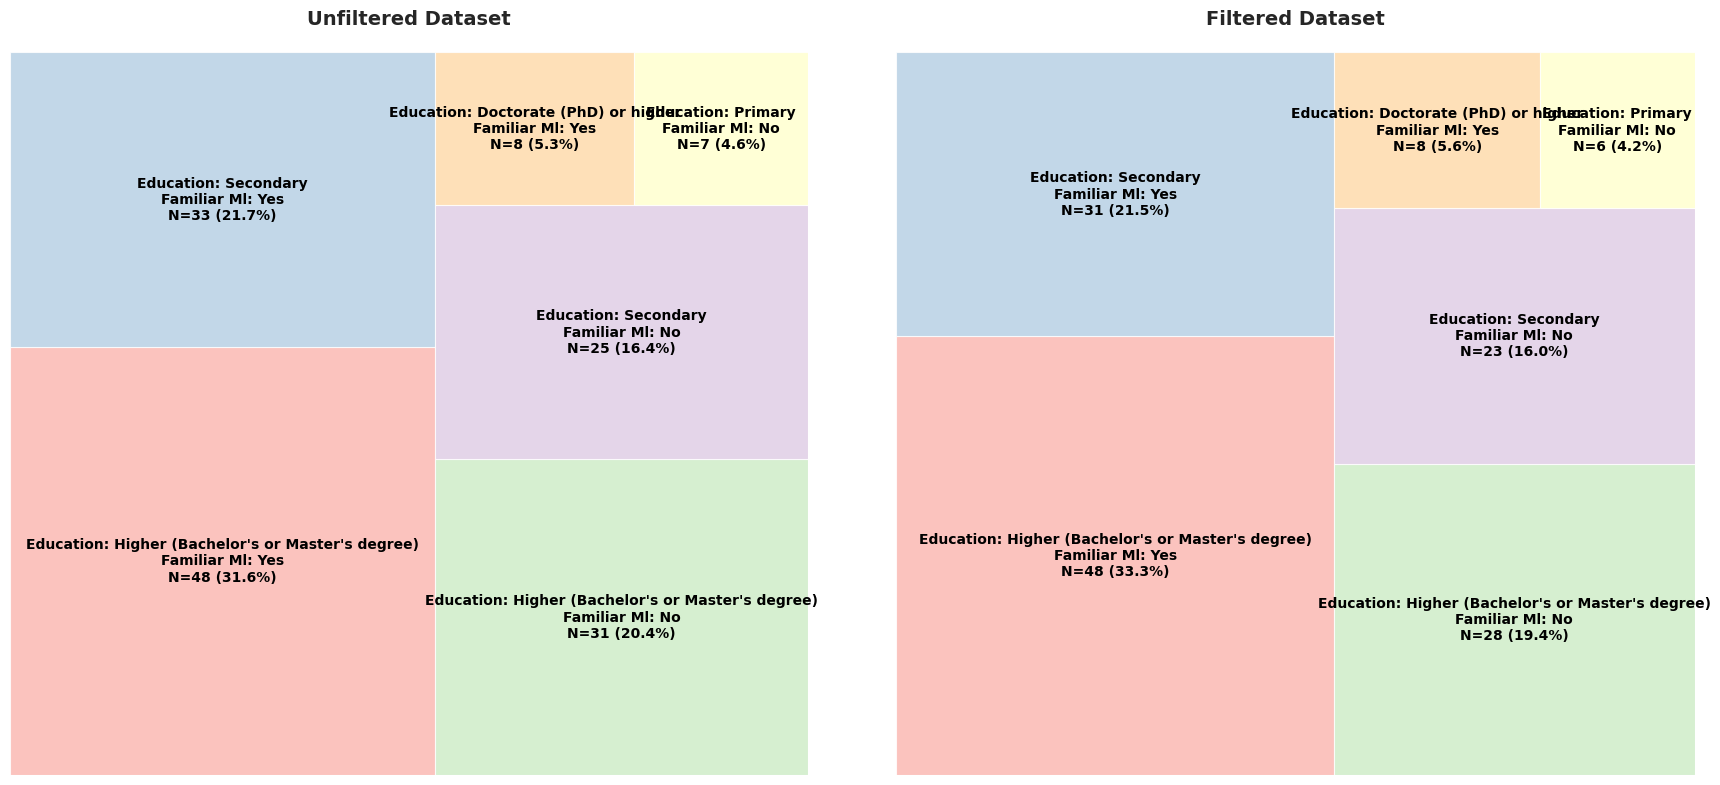

--- Statistical Significance (Filtered vs Excluded) ---
Education & ML Familiarity: p-value = 0.3178 (Not significant)


In [20]:
def plot_treemap(df_subset, hierarchy_cols, title, ax, color_palette='Pastel1'):
    grouped = df_subset.groupby(hierarchy_cols).size().reset_index(name='count')
    grouped = grouped[grouped['count'] > 0].sort_values(by='count', ascending=False)
    total = grouped['count'].sum()
    labels = []
    for _, row in grouped.iterrows():
        label_parts = [f"{col.replace('_', ' ').title()}: {row[col]}" for col in hierarchy_cols]
        pct = (row['count'] / total) * 100
        label = "\n".join(label_parts) + f"\nN={row['count']} ({pct:.1f}%)"
        labels.append(label)
    colors = sns.color_palette(color_palette, len(grouped))
    squarify.plot(sizes=grouped['count'], label=labels, color=colors, alpha=0.8, 
                  text_kwargs={'fontsize': 10, 'weight': 'bold', 'color': 'black'}, ax=ax)
    ax.set_title(title, fontweight='bold', pad=20, fontsize=14)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
df_p1_unf = df_unfiltered.copy()
df_p1_unf['education'] = df_p1_unf['education'].fillna('Not Specified')
df_p1_unf['familiar_ml'] = df_p1_unf['familiar_ml'].fillna('Not Specified')
plot_treemap(df_p1_unf, ['education', 'familiar_ml'], 'Unfiltered Dataset', axes[0])

df_p1_fil = df_filtered.copy()
df_p1_fil['education'] = df_p1_fil['education'].fillna('Not Specified')
df_p1_fil['familiar_ml'] = df_p1_fil['familiar_ml'].fillna('Not Specified')
plot_treemap(df_p1_fil, ['education', 'familiar_ml'], 'Filtered Dataset', axes[1])
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
df_p1_exc = df_excluded.copy()
df_p1_exc['education'] = df_p1_exc['education'].fillna('Not Specified')
df_p1_exc['familiar_ml'] = df_p1_exc['familiar_ml'].fillna('Not Specified')

df_p1_fil['combined'] = df_p1_fil['education'] + "_" + df_p1_fil['familiar_ml']
df_p1_exc['combined'] = df_p1_exc['education'] + "_" + df_p1_exc['familiar_ml']
counts_fil = df_p1_fil['combined'].value_counts()
counts_exc = df_p1_exc['combined'].value_counts()
all_keys = list(set(counts_fil.keys()).union(set(counts_exc.keys())))
run_chi2([[counts_fil.get(k, 0) for k in all_keys], [counts_exc.get(k, 0) for k in all_keys]], "Education & ML Familiarity")


## 6. Sunburst: Education Hierarchy

In [21]:
def get_sunburst_data(df):
    df_p2 = df.copy()
    pipeline_cols = ['education', 'education_field', 'engineering_specialization']
    cleanup_values = ['N/A', '', ' ', 'nan', 'NaN', 'None', '<NA>']
    df_p2[pipeline_cols] = df_p2[pipeline_cols].replace(cleanup_values, np.nan)
    
    ids = []
    labels = []
    parents = []
    values = []
    for ed, df_ed in df_p2.groupby('education', dropna=False):
        if pd.isna(ed): continue
        ed_id = str(ed)
        ids.append(ed_id)
        labels.append(str(ed))
        parents.append("")
        values.append(len(df_ed))
        for field, df_field in df_ed.groupby('education_field', dropna=False):
            if pd.isna(field): continue
            field_id = f"{ed_id}|{field}"
            ids.append(field_id)
            labels.append(str(field))
            parents.append(ed_id)
            values.append(len(df_field))
            for spec, df_spec in df_field.groupby('engineering_specialization', dropna=False):
                if pd.isna(spec): continue
                spec_id = f"{field_id}|{spec}"
                ids.append(spec_id)
                labels.append(str(spec))
                parents.append(field_id)
                values.append(len(df_spec))
    return ids, labels, parents, values

ids_unf, labels_unf, parents_unf, values_unf = get_sunburst_data(df_unfiltered)
ids_fil, labels_fil, parents_fil, values_fil = get_sunburst_data(df_filtered)

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "sunburst"}, {"type": "sunburst"}]], subplot_titles=("Unfiltered", "Filtered"))
fig.add_trace(go.Sunburst(ids=ids_unf, labels=labels_unf, parents=parents_unf, values=values_unf, branchvalues="total", textinfo="label+value", insidetextorientation='radial'), row=1, col=1)
fig.add_trace(go.Sunburst(ids=ids_fil, labels=labels_fil, parents=parents_fil, values=values_fil, branchvalues="total", textinfo="label+value", insidetextorientation='radial'), row=1, col=2)
fig.update_layout(title="Education Hierarchy", title_font=dict(size=20, family="Arial"), width=1200, height=600, margin=dict(t=60, l=10, r=10, b=10))
fig.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
counts_fil = df_filtered['education_field'].fillna('Missing').value_counts()
counts_exc = df_excluded['education_field'].fillna('Missing').value_counts()
all_keys = list(set(counts_fil.keys()).union(set(counts_exc.keys())))
run_chi2([[counts_fil.get(k, 0) for k in all_keys], [counts_exc.get(k, 0) for k in all_keys]], "Education Field")


--- Statistical Significance (Filtered vs Excluded) ---
Education Field: p-value = 0.6628 (Not significant)


## 7. Treemap: Knowledge ML, XAI and Counterfactuals

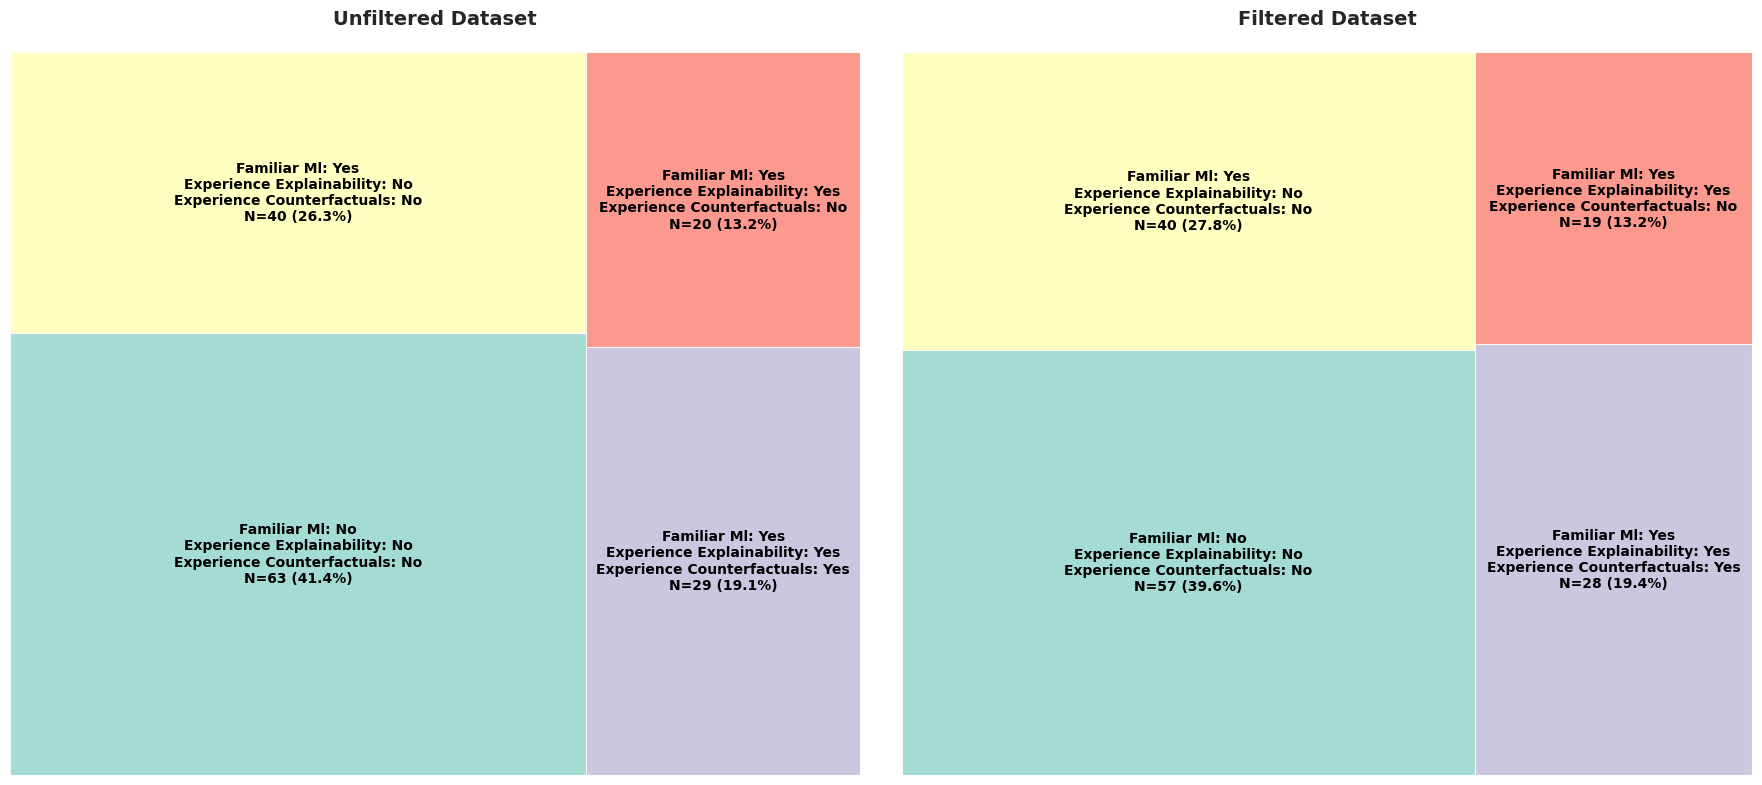

--- Statistical Significance (Filtered vs Excluded) ---
Knowledge ML, XAI, CFEs: p-value = 0.1943 (Not significant)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
pipeline_cols = ['familiar_ml', 'experience_explainability', 'experience_counterfactuals']

df_p2_unf = df_unfiltered.copy()
df_p2_unf[pipeline_cols] = df_p2_unf[pipeline_cols].fillna('No')
plot_treemap(df_p2_unf, pipeline_cols, 'Unfiltered Dataset', axes[0], color_palette='Set3')

df_p2_fil = df_filtered.copy()
df_p2_fil[pipeline_cols] = df_p2_fil[pipeline_cols].fillna('No')
plot_treemap(df_p2_fil, pipeline_cols, 'Filtered Dataset', axes[1], color_palette='Set3')
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
df_p2_exc = df_excluded.copy()
df_p2_exc[pipeline_cols] = df_p2_exc[pipeline_cols].fillna('No')
df_p2_fil['combined'] = df_p2_fil[pipeline_cols].apply(lambda x: "_".join(x.astype(str)), axis=1)
df_p2_exc['combined'] = df_p2_exc[pipeline_cols].apply(lambda x: "_".join(x.astype(str)), axis=1)
counts_fil = df_p2_fil['combined'].value_counts()
counts_exc = df_p2_exc['combined'].value_counts()
all_keys = list(set(counts_fil.keys()).union(set(counts_exc.keys())))
run_chi2([[counts_fil.get(k, 0) for k in all_keys], [counts_exc.get(k, 0) for k in all_keys]], "Knowledge ML, XAI, CFEs")


## 8. Stacked Bar Plots: Demographics & Explainability Need

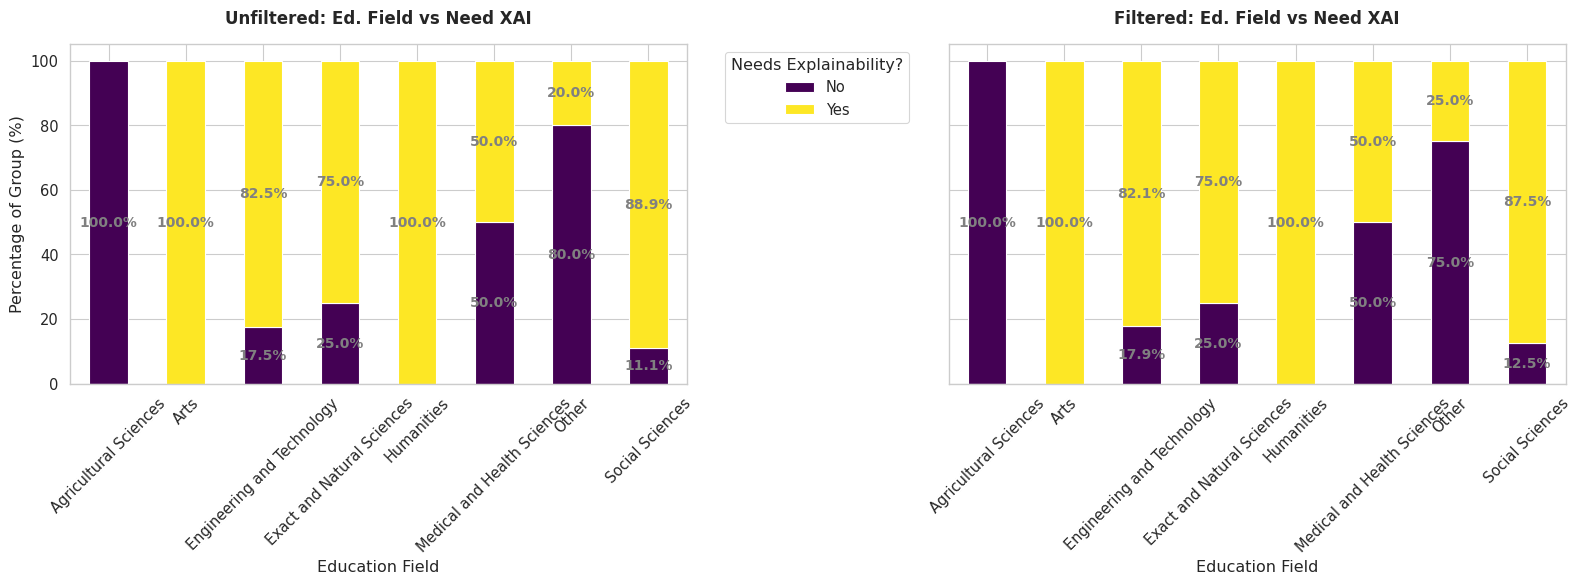

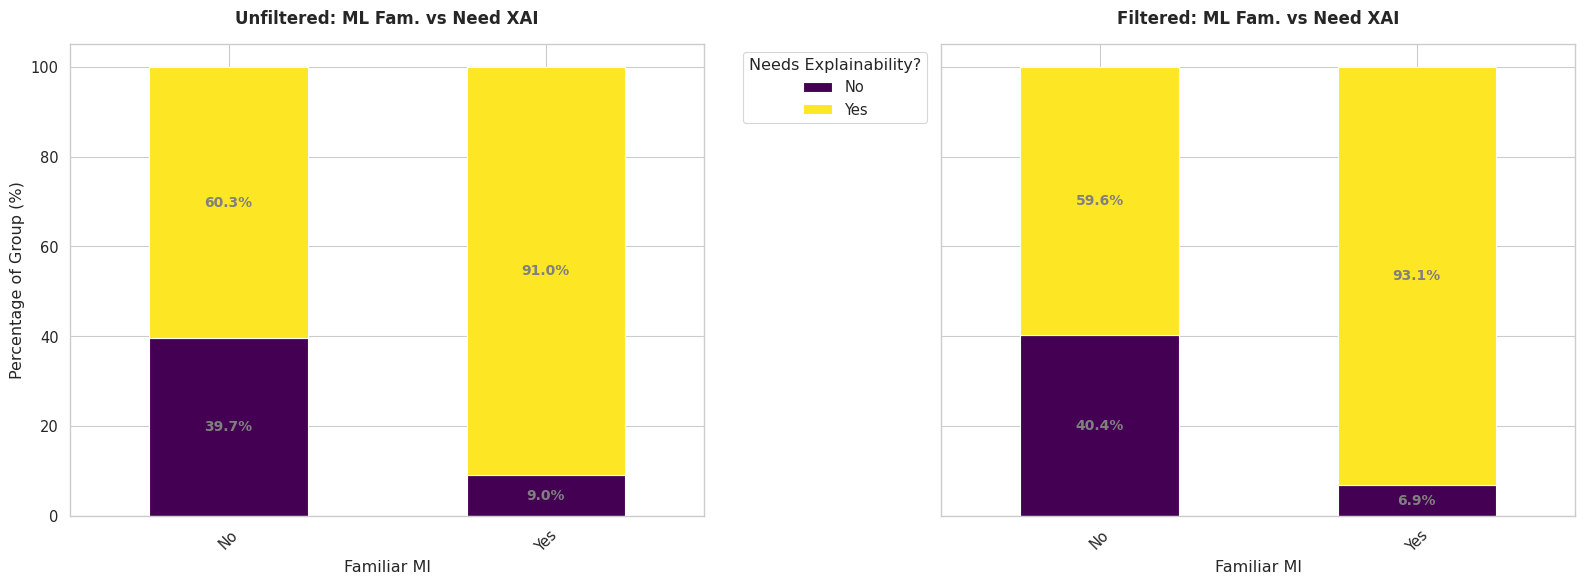

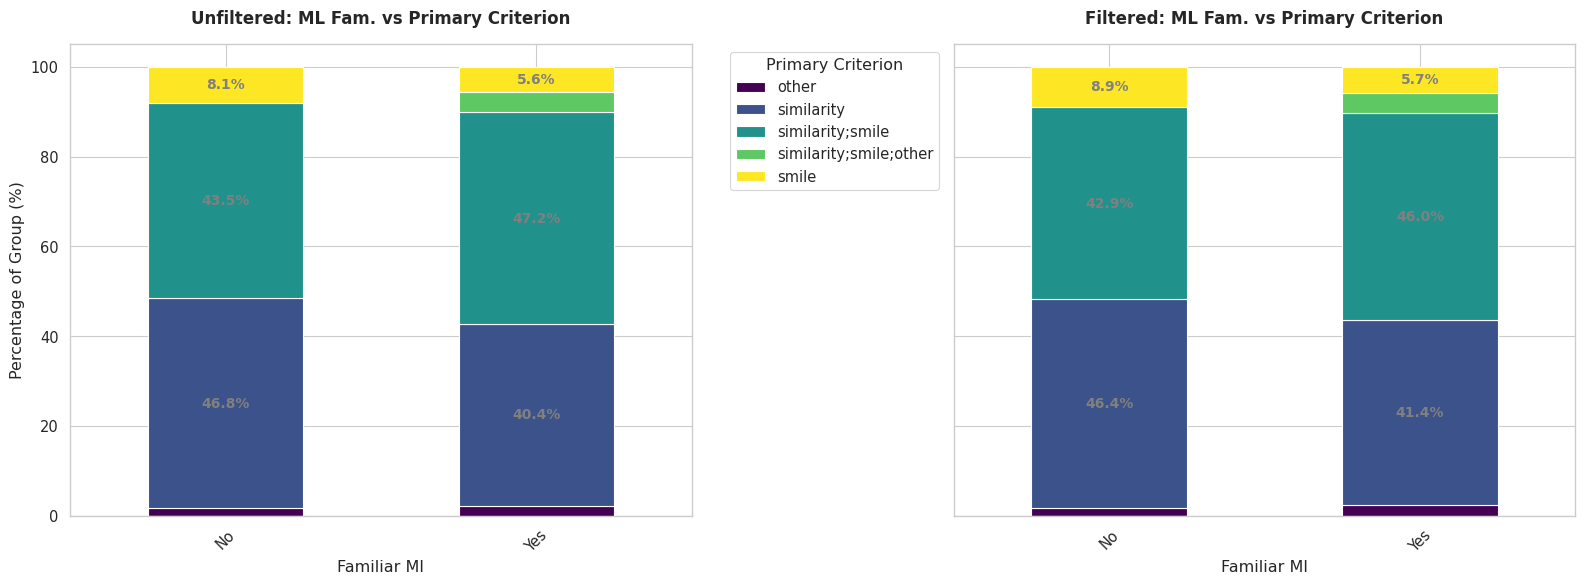

--- Statistical Significance (Filtered vs Excluded) ---
Education Field vs Need XAI: p-value = 0.4520 (Not significant)
ML Familiarity vs Need XAI: p-value = 0.0042 (*** SIGNIFICANT ***)


In [23]:
def plot_100_percent_stacked(df_source, col_x, col_hue, ax, title):
    temp_df = df_source.dropna(subset=[col_x, col_hue]).copy()
    if len(temp_df) == 0: return
    crosstab = pd.crosstab(temp_df[col_x], temp_df[col_hue], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='white')
    ax.set_title(title, fontweight='bold', pad=15, fontsize=12)
    ax.set_ylabel('Percentage of Group (%)')
    ax.set_xlabel(col_x.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    for c in ax.containers:
        labels = [f'{w:.1f}%' if w > 5 else '' for w in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='gray', weight='bold', fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_100_percent_stacked(df_unfiltered, 'education_field', 'need_explainability', axes[0], 'Unfiltered: Ed. Field vs Need XAI')
plot_100_percent_stacked(df_filtered, 'education_field', 'need_explainability', axes[1], 'Filtered: Ed. Field vs Need XAI')
axes[0].legend(title='Needs Explainability?', bbox_to_anchor=(1.05, 1), loc='upper left')
if axes[1].get_legend(): axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_100_percent_stacked(df_unfiltered, 'familiar_ml', 'need_explainability', axes[0], 'Unfiltered: ML Fam. vs Need XAI')
plot_100_percent_stacked(df_filtered, 'familiar_ml', 'need_explainability', axes[1], 'Filtered: ML Fam. vs Need XAI')
axes[0].legend(title='Needs Explainability?', bbox_to_anchor=(1.05, 1), loc='upper left')
if axes[1].get_legend(): axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
temp_unf = df_unfiltered[df_unfiltered['q_most_important_criterion'] != 'Not Specified']
temp_fil = df_filtered[df_filtered['q_most_important_criterion'] != 'Not Specified']
plot_100_percent_stacked(temp_unf, 'familiar_ml', 'q_most_important_criterion', axes[0], 'Unfiltered: ML Fam. vs Primary Criterion')
plot_100_percent_stacked(temp_fil, 'familiar_ml', 'q_most_important_criterion', axes[1], 'Filtered: ML Fam. vs Primary Criterion')
axes[0].legend(title='Primary Criterion', bbox_to_anchor=(1.05, 1), loc='upper left')
if axes[1].get_legend(): axes[1].get_legend().remove()
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
# To test if the relationships themselves differ, we'd need a 3-way interaction, 
# but simply testing the joint distribution is easier:
df_fil_comb = df_filtered['education_field'].astype(str) + "_" + df_filtered['need_explainability'].astype(str)
df_exc_comb = df_excluded['education_field'].astype(str) + "_" + df_excluded['need_explainability'].astype(str)
c_fil, c_exc = df_fil_comb.value_counts(), df_exc_comb.value_counts()
all_keys = list(set(c_fil.keys()).union(set(c_exc.keys())))
run_chi2([[c_fil.get(k, 0) for k in all_keys], [c_exc.get(k, 0) for k in all_keys]], "Education Field vs Need XAI")

df_fil_comb2 = df_filtered['familiar_ml'].astype(str) + "_" + df_filtered['need_explainability'].astype(str)
df_exc_comb2 = df_excluded['familiar_ml'].astype(str) + "_" + df_excluded['need_explainability'].astype(str)
c_fil2, c_exc2 = df_fil_comb2.value_counts(), df_exc_comb2.value_counts()
all_keys2 = list(set(c_fil2.keys()).union(set(c_exc2.keys())))
run_chi2([[c_fil2.get(k, 0) for k in all_keys2], [c_exc2.get(k, 0) for k in all_keys2]], "ML Familiarity vs Need XAI")


## 9. Mean Rank per Selector Grouped by Demographics

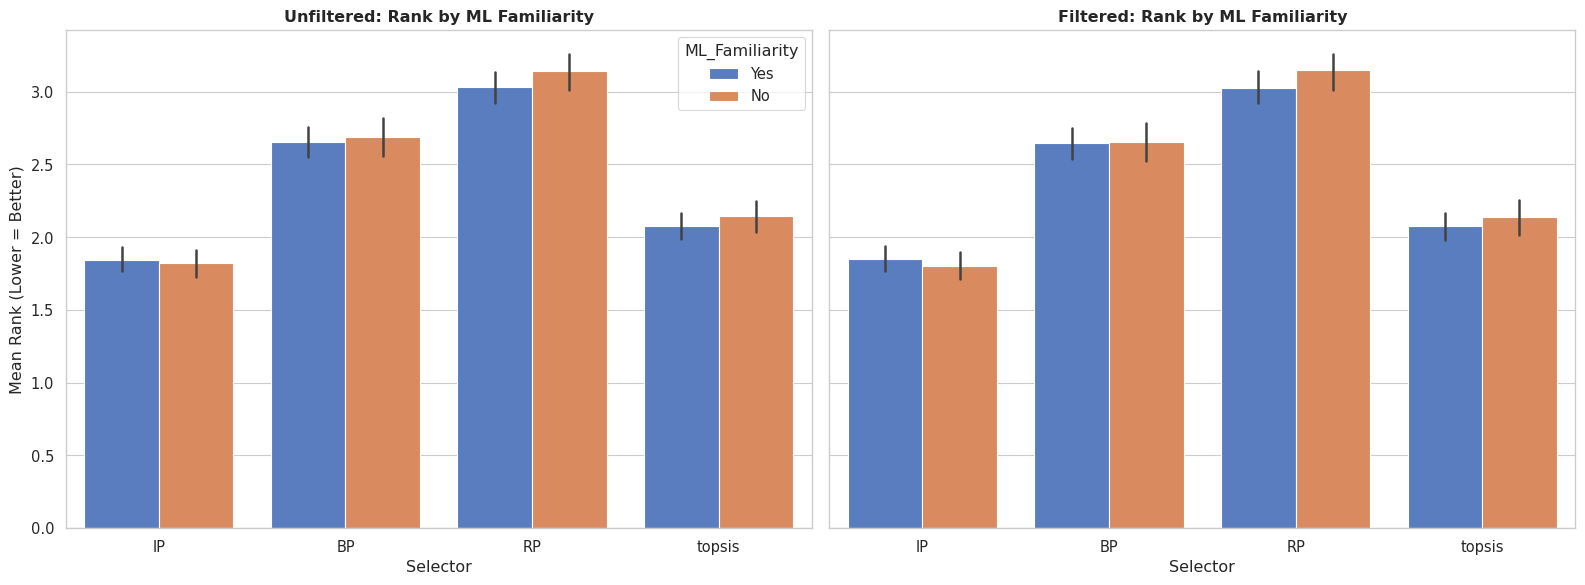

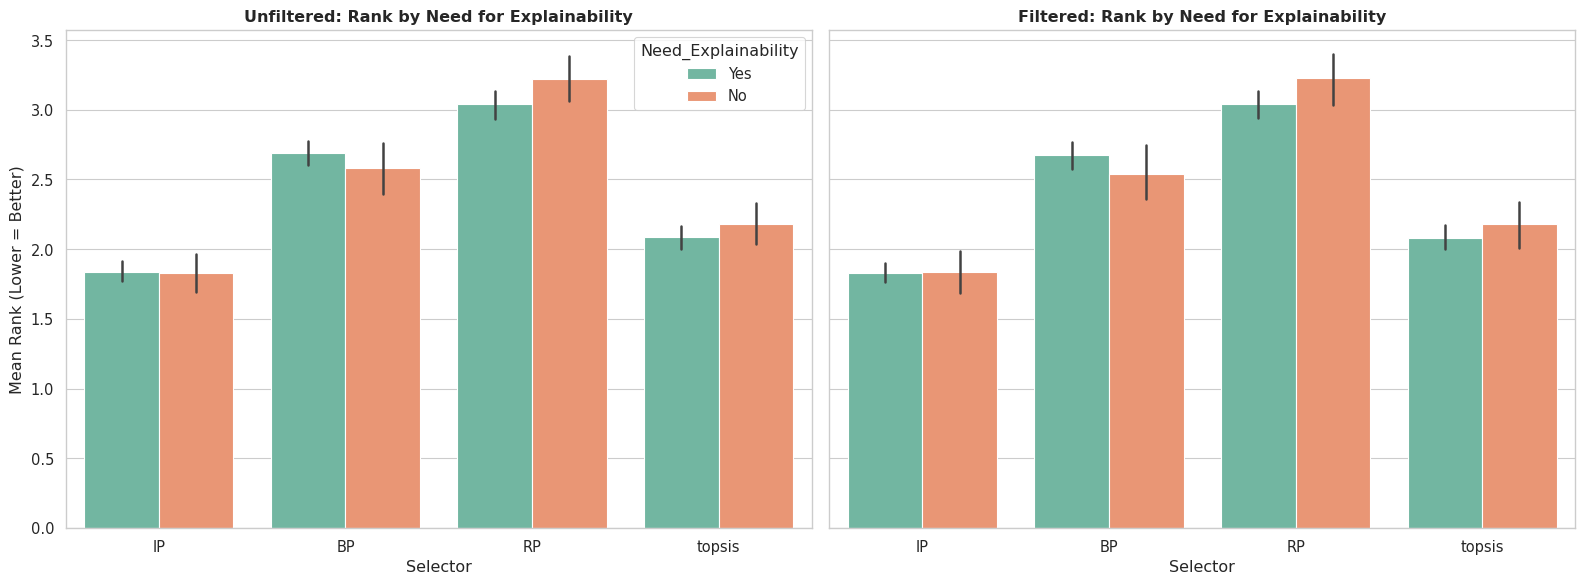

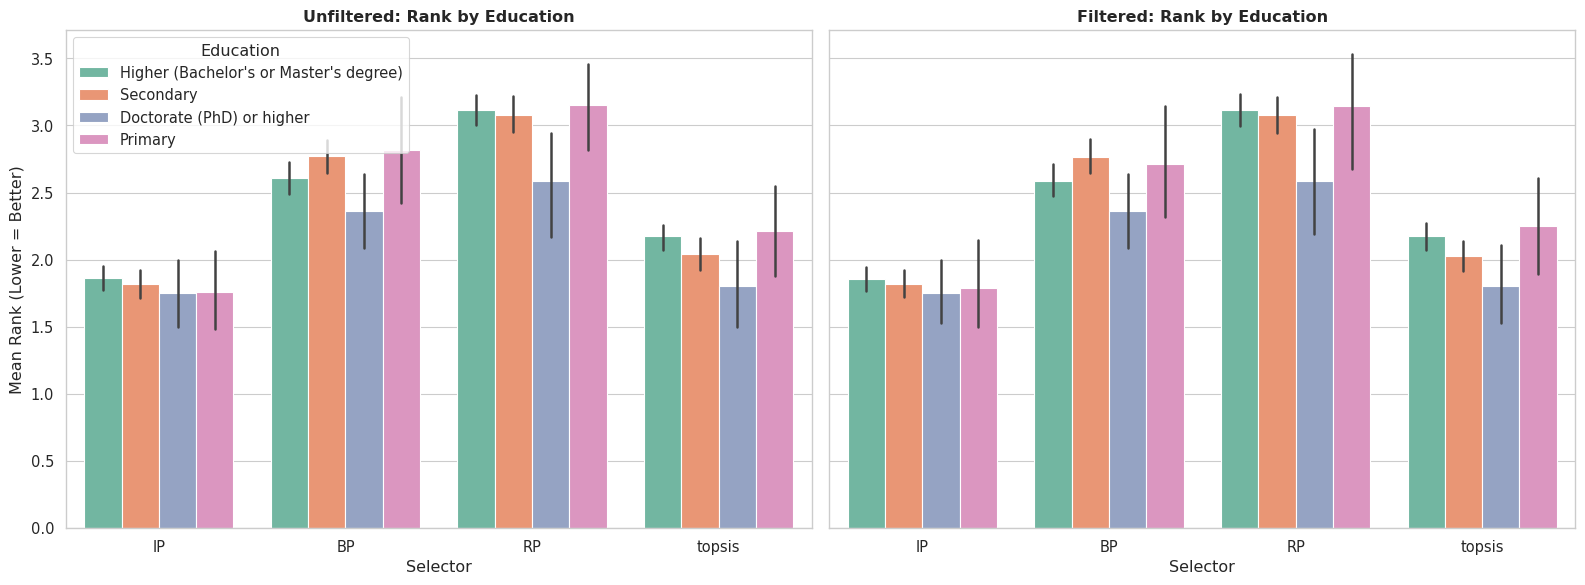

--- Statistical Significance (Filtered vs Excluded - Mann-Whitney U on Ranks) ---
Selector 'IP' Overall Mean Rank: p-value = 0.8859 (Not significant)
Selector 'BP' Overall Mean Rank: p-value = 0.0491 (*** SIGNIFICANT ***)
Selector 'RP' Overall Mean Rank: p-value = 0.7657 (Not significant)
Selector 'topsis' Overall Mean Rank: p-value = 0.5612 (Not significant)


In [24]:
def get_melted_ranks(df):
    melted_rows = []
    for idx, row in df.iterrows():
        for q in ranking_qs:
            for s in selectors:
                col = f"{q}_{s}_pos"
                if col in df.columns and pd.notna(row[col]):
                    melted_rows.append({
                        'Subject_ID': idx, 'Selector': s, 'Rank': row[col],
                        'ML_Familiarity': row.get('familiar_ml', 'Unknown'),
                        'Education': row.get('education', 'Unknown'),
                        'Need_Explainability': row.get('need_explainability', 'Unknown')
                    })
    return pd.DataFrame(melted_rows)

df_ranks_unf = get_melted_ranks(df_unfiltered)
df_ranks_fil = get_melted_ranks(df_filtered)
df_ranks_exc = get_melted_ranks(df_excluded)

def plot_mean_ranks(col_hue, title_suffix, palette):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    sns.barplot(data=df_ranks_unf, x='Selector', y='Rank', hue=col_hue, errorbar=('ci', 95), palette=palette, ax=axes[0])
    sns.barplot(data=df_ranks_fil, x='Selector', y='Rank', hue=col_hue, errorbar=('ci', 95), palette=palette, ax=axes[1])
    axes[0].set_title(f'Unfiltered: {title_suffix}', fontweight='bold')
    axes[1].set_title(f'Filtered: {title_suffix}', fontweight='bold')
    axes[0].set_ylabel('Mean Rank (Lower = Better)')
    axes[1].set_ylabel('')
    if axes[1].get_legend(): axes[1].get_legend().remove()
    plt.tight_layout()
    plt.show()

plot_mean_ranks('ML_Familiarity', 'Rank by ML Familiarity', 'muted')
plot_mean_ranks('Need_Explainability', 'Rank by Need for Explainability', 'Set2')
plot_mean_ranks('Education', 'Rank by Education', 'Set2')

print("--- Statistical Significance (Filtered vs Excluded - Mann-Whitney U on Ranks) ---")
for s in selectors:
    f_ranks = df_ranks_fil[df_ranks_fil['Selector'] == s]['Rank']
    e_ranks = df_ranks_exc[df_ranks_exc['Selector'] == s]['Rank']
    if len(f_ranks) > 0 and len(e_ranks) > 0:
        stat, p = mannwhitneyu(f_ranks, e_ranks, alternative='two-sided')
        sig = "*** SIGNIFICANT ***" if p < 0.05 else "Not significant"
        print(f"Selector '{s}' Overall Mean Rank: p-value = {p:.4f} ({sig})")


## 10. Data Mining / Model Processing

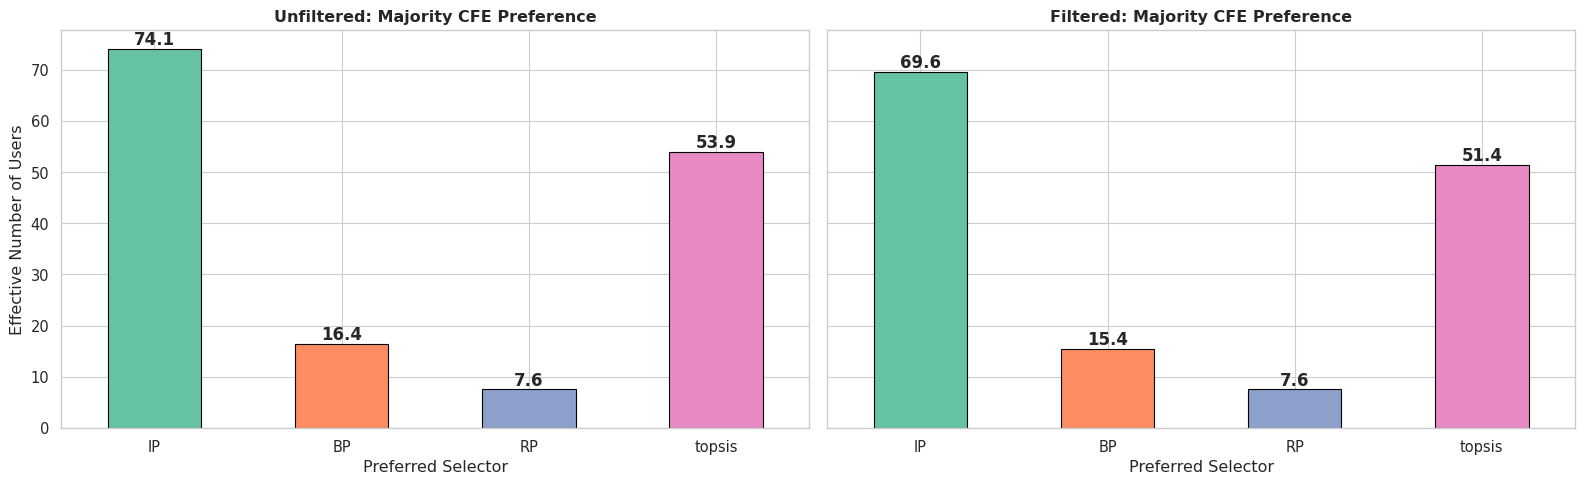

--- Statistical Significance (Filtered vs Excluded) ---
Majority CFE Preference: p-value = 0.9001 (Not significant)


In [25]:
def process_user_data(df):
    if len(df) == 0: return pd.DataFrame(), pd.DataFrame(), pd.Series(), []
    
    topsis_col = 'q15_topsis_pos'
    ip_col = 'q15_IP_pos'
    if topsis_col in df.columns and ip_col in df.columns:
        df['q15_dupe_dist'] = (df[topsis_col] - df[ip_col]).abs()
        df['passed_attention'] = (df['q15_dupe_dist'].le(1) | df['q15_dupe_dist'].isna()).astype(int)
    else:
        df['passed_attention'] = 1
        
    demographics = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 
                    'experience_counterfactuals', 'need_explainability', 
                    'education', 'education_field', 'q_most_important_criterion', 'passed_attention']
    for d in demographics:
        if d not in df.columns: df[d] = 'Missing'
    df[demographics] = df[demographics].fillna('Missing')
    user_data = []
    for idx, row in df.iterrows():
        top_choices = []
        for q in ['q1', 'q5', 'q7', 'q13', 'q15']:
            for s in selectors:
                col = f"{q}_{s}_pos"
                if col in df.columns and row[col] == 1.0:
                    top_choices.append(s)
        if top_choices:
            modes = pd.Series(top_choices).mode().tolist()
            weight = 1.0 / len(modes)
            for m in modes:
                entry = {d: row[d] for d in demographics}
                entry['Subject_ID'] = idx
                entry['overall_top_selector'] = m
                entry['sample_weight'] = weight
                user_data.append(entry)
    
    df_user = pd.DataFrame(user_data)
    if len(df_user) == 0: return pd.DataFrame(), pd.DataFrame(), pd.Series(), []
    
    knowledge_cols = ['familiar_ml', 'familiar_metrics', 'experience_explainability', 'experience_counterfactuals']
    df_user['xai_expertise'] = df_user[knowledge_cols].apply(lambda x: sum(x == 'Yes'), axis=1)
    stem_fields = ['Engineering and Technology', 'Exact and Natural Sciences', 'Medical and Health Sciences', 'Agricultural Sciences']
    df_user['is_stem'] = df_user['education_field'].apply(lambda x: 'Yes' if x in stem_fields else 'No')
    df_user['crit_similarity'] = df_user['q_most_important_criterion'].apply(lambda x: 1 if pd.notna(x) and 'similarity' in str(x) else 0)
    df_user['crit_smile'] = df_user['q_most_important_criterion'].apply(lambda x: 1 if pd.notna(x) and 'smile' in str(x) else 0)
    df_user['crit_other'] = df_user['q_most_important_criterion'].apply(lambda x: 1 if pd.notna(x) and 'other' in str(x) else 0)
    
    modeling_features = ['xai_expertise', 'is_stem', 'need_explainability', 'crit_similarity', 'crit_smile', 'crit_other', 'passed_attention']
    X = df_user[modeling_features].copy()
    cats_to_encode = ['is_stem', 'need_explainability']
    for col in cats_to_encode:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    return df_user, X, df_user['overall_top_selector'], modeling_features

df_user_unf, X_unf, y_unf, features_unf = process_user_data(df_unfiltered.copy())
df_user_fil, X_fil, y_fil, features_fil = process_user_data(df_filtered.copy())
df_user_exc, X_exc, y_exc, features_exc = process_user_data(df_excluded.copy())

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
weighted_unf = df_user_unf.groupby('overall_top_selector')['sample_weight'].sum().reindex(['IP', 'BP', 'RP', 'topsis']).fillna(0)
weighted_fil = df_user_fil.groupby('overall_top_selector')['sample_weight'].sum().reindex(['IP', 'BP', 'RP', 'topsis']).fillna(0)

weighted_unf.plot(kind='bar', color=sns.color_palette('Set2', 4), edgecolor='black', ax=axes[0])
weighted_fil.plot(kind='bar', color=sns.color_palette('Set2', 4), edgecolor='black', ax=axes[1])
axes[0].set_title('Unfiltered: Majority CFE Preference', fontweight='bold')
axes[1].set_title('Filtered: Majority CFE Preference', fontweight='bold')
for i, ax in enumerate(axes):
    ax.set_xlabel('Preferred Selector')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Effective Number of Users')
plt.tight_layout()
plt.show()

print("--- Statistical Significance (Filtered vs Excluded) ---")
if len(df_user_exc) > 0:
    weighted_exc = df_user_exc.groupby('overall_top_selector')['sample_weight'].sum().reindex(['IP', 'BP', 'RP', 'topsis']).fillna(0)
    run_chi2([list(weighted_fil.values), list(weighted_exc.values)], "Majority CFE Preference")


## 11. Feature Importances for Predicting Top CFE Selector

/tmp/ipykernel_32505/2286341143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis', ax=ax)
/tmp/ipykernel_32505/2286341143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis', ax=ax)


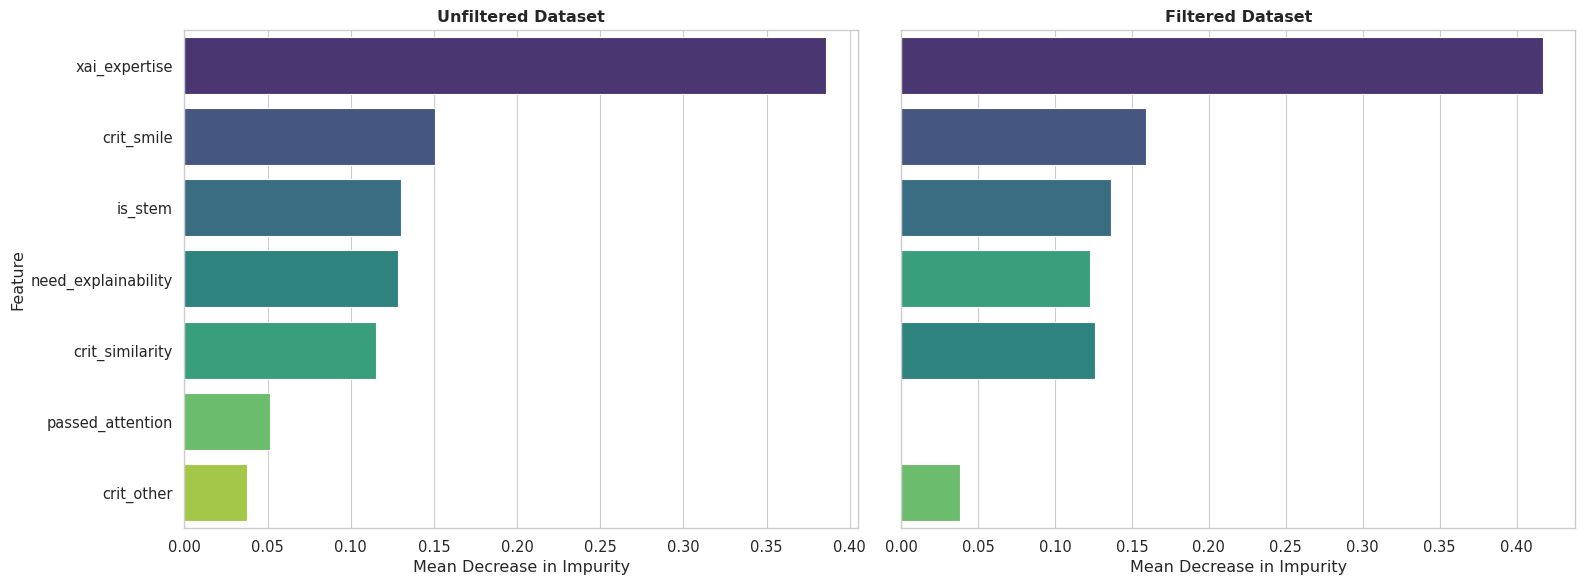

In [26]:
def plot_feature_importances(X, y, sample_weight, ax, title):
    if len(X) == 0: return
    rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
    rf.fit(X, y, sample_weight=sample_weight)
    importances = rf.feature_importances_
    df_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
    sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean Decrease in Impurity')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_feature_importances(X_unf, y_unf, df_user_unf['sample_weight'], axes[0], 'Unfiltered Dataset')
plot_feature_importances(X_fil, y_fil, df_user_fil['sample_weight'], axes[1], 'Filtered Dataset')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


## 12. Statistical Significance of Demographics on User Preference

/tmp/ipykernel_32505/2794721636.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_chi, x='p_value', y='Feature', palette='coolwarm_r', ax=ax)
/tmp/ipykernel_32505/2794721636.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_chi, x='p_value', y='Feature', palette='coolwarm_r', ax=ax)


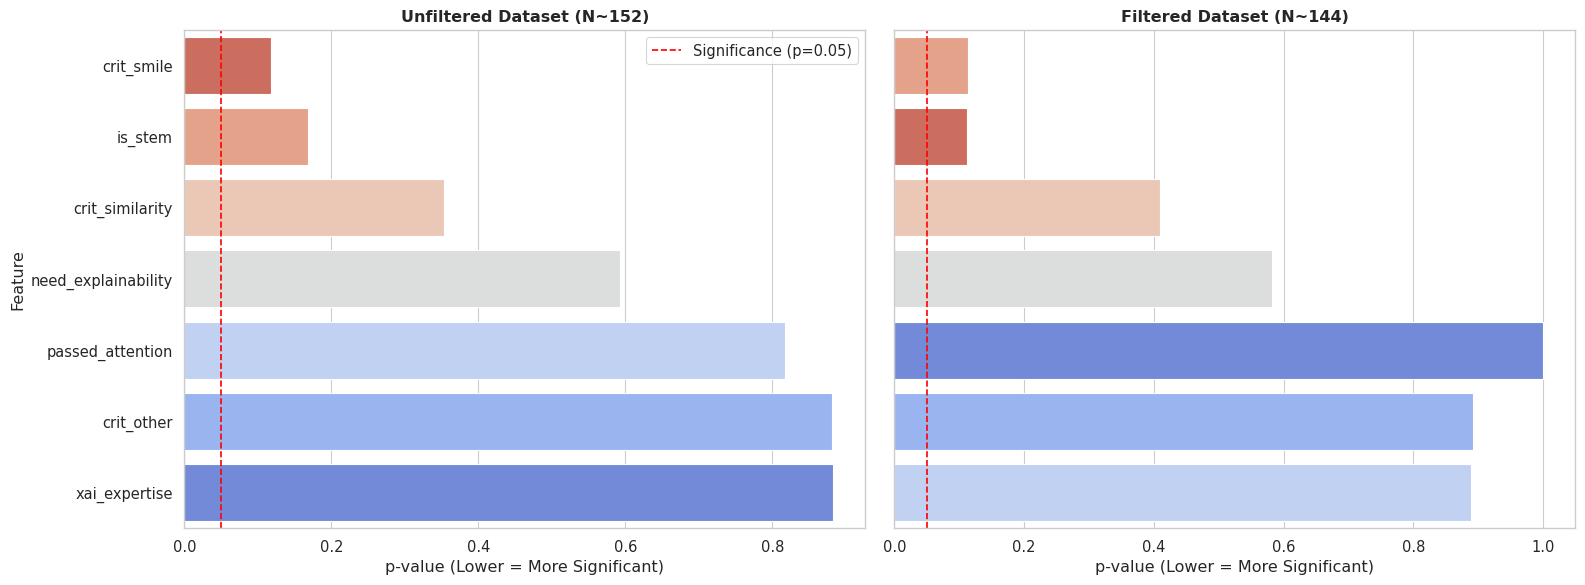

In [27]:
def plot_significance(df_user, features, ax, title, N):
    if len(df_user) == 0: return
    chi_results = []
    for d in features:
        contingency = pd.crosstab(df_user[d], df_user['overall_top_selector'])
        try:
            chi2, p, dof, expected = chi2_contingency(contingency)
            chi_results.append({'Feature': d, 'p_value': p})
        except:
            chi_results.append({'Feature': d, 'p_value': 1.0})
    df_chi = pd.DataFrame(chi_results).sort_values('p_value')
    sns.barplot(data=df_chi, x='p_value', y='Feature', palette='coolwarm_r', ax=ax)
    ax.axvline(0.05, color='red', linestyle='--', label='Significance (p=0.05)')
    ax.set_title(f"{title} (N~{N})", fontweight='bold')
    ax.set_xlabel('p-value (Lower = More Significant)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
plot_significance(df_user_unf, features_unf, axes[0], 'Unfiltered Dataset', len(df_unfiltered))
plot_significance(df_user_fil, features_fil, axes[1], 'Filtered Dataset', len(df_filtered))
axes[0].legend()
if axes[1].get_legend(): axes[1].legend()
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

# Note: This plot itself displays the p-values for demographics vs preferences within each dataset.


## 13. User-Level Selector Preference Tree

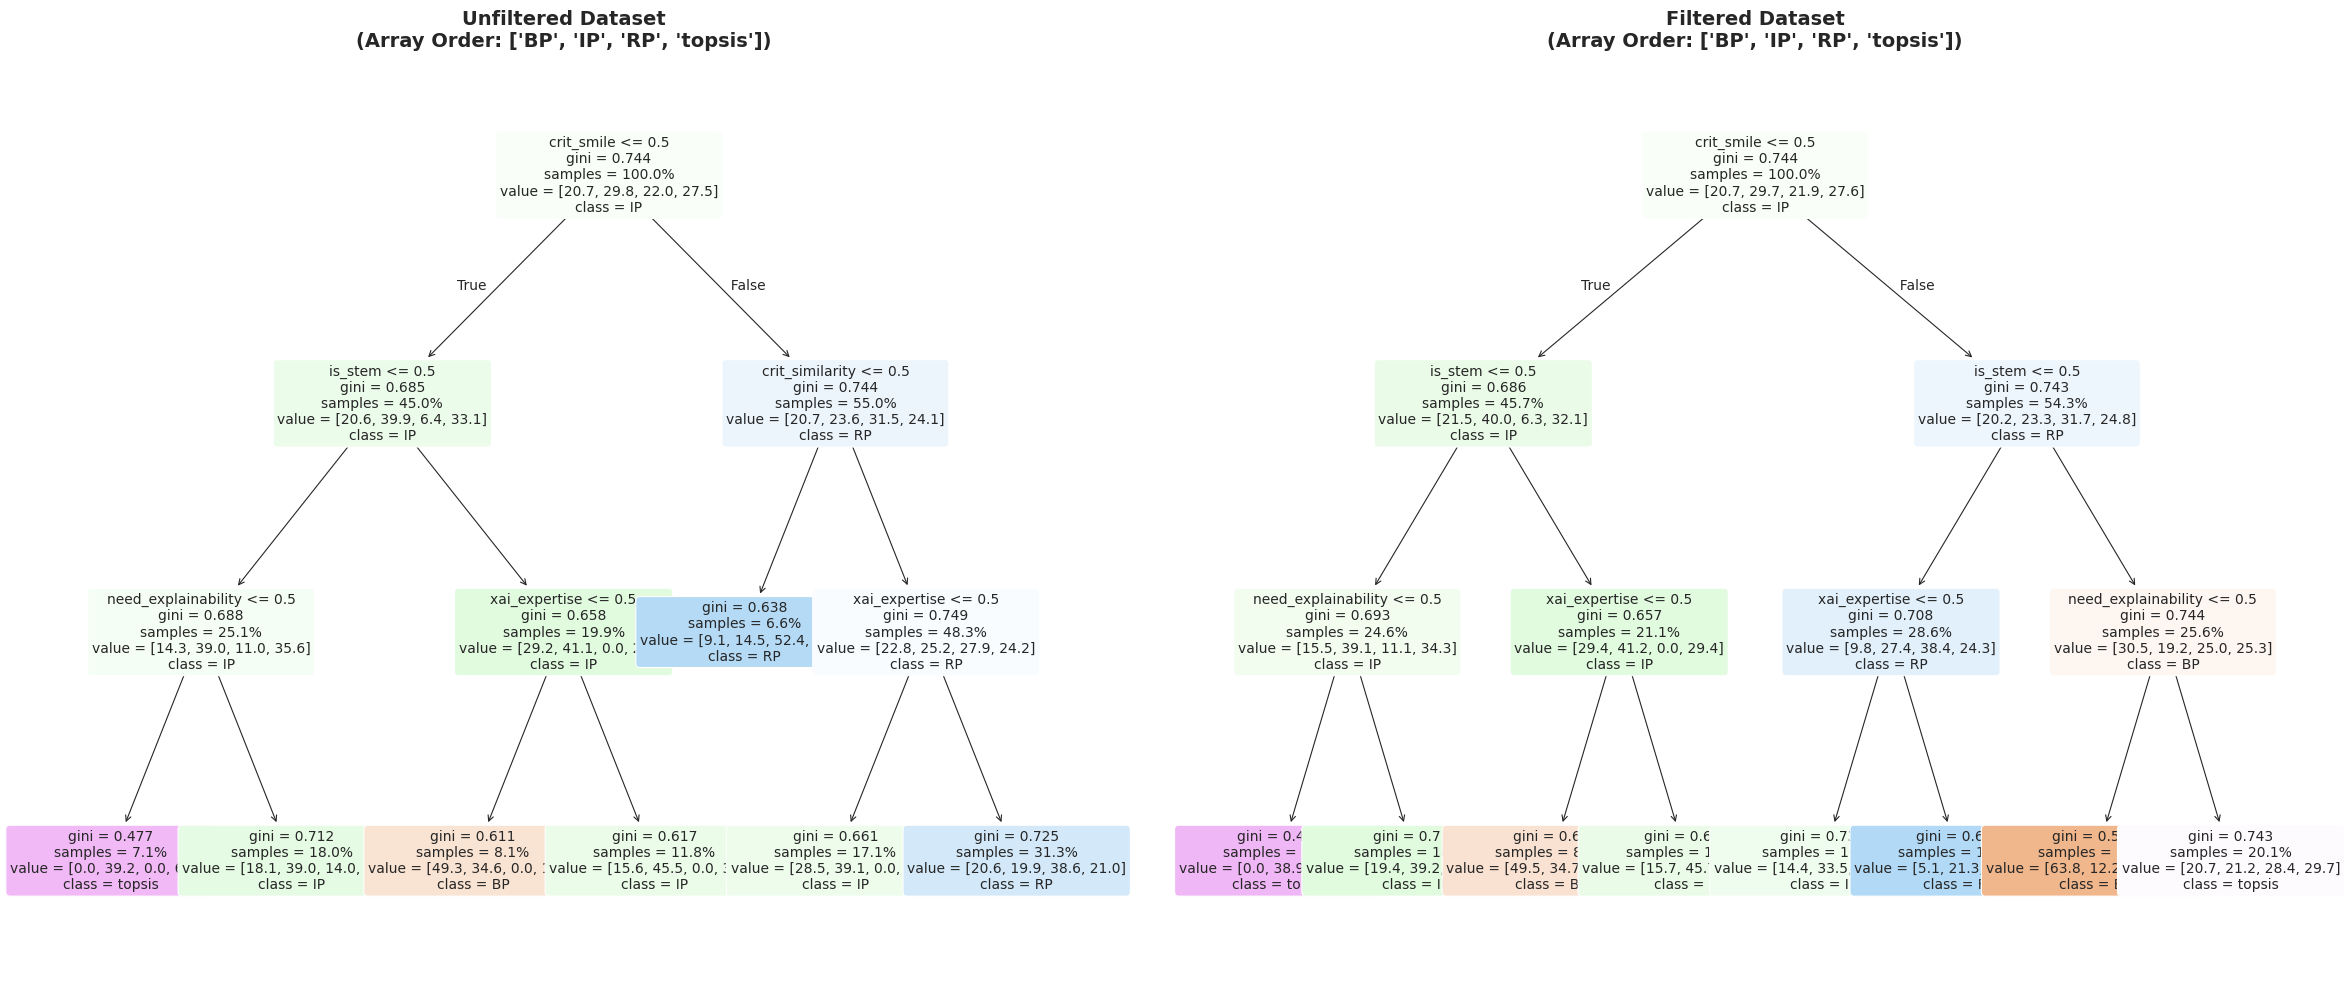

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

def plot_dt(X, y, sample_weight, ax, title):
    if len(X) == 0: return
    dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced', min_samples_leaf=10)
    dt.fit(X, y, sample_weight=sample_weight)
    plot_tree(dt, feature_names=X.columns, class_names=dt.classes_, filled=True, rounded=True, 
              fontsize=10, ax=ax, proportion=True)
    for text_obj in ax.texts:
        text = text_obj.get_text()
        lines = text.split('\n')
        for i, line in enumerate(lines):
            if line.startswith('value'):
                import re
                match = re.search(r'\[(.*?)\]', line)
                if match:
                    vals = [round(float(x.strip()) * 100, 2 ) for x in match.group(1).split(',')]
                    lines[i] = f"value = {vals}"
        text_obj.set_text('\n'.join(lines))
    ax.set_title(f"{title}\n(Array Order: {list(dt.classes_)})", fontsize=14, fontweight='bold', pad=10)

plot_dt(X_unf, y_unf, df_user_unf['sample_weight'], axes[0], 'Unfiltered Dataset')
plot_dt(X_fil, y_fil, df_user_fil['sample_weight'], axes[1], 'Filtered Dataset')
plt.tight_layout()
plt.show()
